**Adult Income Prediction**   
Classification Project using Logistic Regression, KNN, and SVM

**Author:** Kate  
**Project Type:** Supervised Machine Learning Classification  
**Dataset:** Adult Income Dataset  
**Objective:** Predict whether an individual's annual income exceeds \$50K

# <p style="background-color:green;font-family:newtimeroman;font-size:200%;color:white;text-align:center;border-radius:20px 20px;"><b>Adult Income Prediction Project Solution</b></p>
![](https://www.techproeducation.com/logo/headerlogo.svg)

<b>If you want to be the first to get informed of the most recent updates, then don't forget to follow us on:</b>[YouTube](https://www.youtube.com/c/techproeducation) | [Instagram](https://www.instagram.com/techproeducation) | [Facebook](https://www.facebook.com/techproeducation) | [Telegram](https://t.me/joinchat/HH2qRvA-ulh4OWbb) | [WhatsApp](https://api.whatsapp.com/send/?phone=%2B15853042959&text&type=phone_number&app_absent=0) | [LinkedIn](https://www.linkedin.com/company/techproeducation/mycompany/) |

**Project Overview**

The goal of this project is to build and evaluate machine learning classification models that predict whether an individual's annual income exceeds \$50K based on demographic and employment-related features.  
This project applies several classification algorithms, including Logistic Regression, K-Nearest Neighbors (KNN), and Support Vector Machine (SVM). The models are evaluated using multiple metrics such as accuracy, confusion matrix, classification report, and ROC-AUC score.   
In addition, hyperparameter tuning and cross-validation are applied to improve model reliability and demonstrate a more professional machine learning workflow.

# <font color='green'> <b>Exploratory Data Analysis</b><font color='black'>

Before building machine learning models, it is important to understand the structure and characteristics of the dataset.
In this section we examine:
- dataset shape
- feature types
- summary statistics
- missing values
- duplicated rows

**Data Set Information:**

This dataset was obtained from UCI Machine Learning Repository. The aim of this problem is to classify adults in two different groups based on their income where group 1 has an income less than USD 50k and group 2 has an income of more than or equal to USD 50k. The data available at hand comes from Census 1994.

**Attribute Information:**

**Age**: Describes the age of individuals. Continuous.

**Workclass**: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.

**fnlwgt**: Continuous value. This is a weighting factor created by the U.S. Census Bureau, indicating the number of people that each data entry represents. For example, if the fnlwgt value for a data entry is 100, it means that this data entry is considered to represent 100 people.

However, this feature is not typically used directly in analyses or model training because these weights don't have a direct significance on individual data points when training or testing models. Nonetheless, these weight values can be useful if a more in-depth demographic analysis of the dataset is being conducted.

**education**: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.

**education-num**: Number of years spent in education. Continuous.

**marital-status**: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.

**occupation**: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.

**relationship**: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.

**race**: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.

**sex**: Female, Male.

**capital-gain**: Represents the profit an individual makes from the sale of assets (e.g., stock or real estate sales). Continuous.

**capital-loss**: Represents the loss an individual incurs from the sale of assets (e.g., stock or real estate sales). Continuous.

**hours-per-week**: Continuous.

**native-country**: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.

**salary**: >50K,<=50K.


In [7]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings("ignore")

In [8]:
# Load Dataset

df = pd.read_csv("adult (1).csv")
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


The **Adult Income Dataset** was loaded into a pandas DataFrame for further analysis.   
The target variable indicates whether the individual's income exceeds **$50K per year**.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


**Dataset Structure**  
The dataset contains **32,561 observations** and **15 features**.  
There are two main types of variables:  
- **Numerical features (6)** such as age, fnlwgt, education.num, capital.gain, capital.loss, and hours.per.week.
- **Categorical features (9)** including workclass, education, marital.status, occupation, relationship, race, sex, native.country, and income.   
The dataset occupies approximately **3.7 MB of memory**, which makes it relatively small and efficient for machine learning experiments.

In [12]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


**Summary Statistics**    
The statistical summary shows the distribution of numerical variables in the dataset.   
Key observations:   
- The **average age** of individuals in the dataset is approximately **38.6 years**.
- The average number of **working hours per week** is around **40 hours**, which aligns with a typical full-time schedule.
- The variables **capital.gain** and **capital.loss** contain many zeros, suggesting that most individuals do not report capital gains or losses.
- The dataset also contains some **large outlier values**, especially in capital.gain and capital.loss.     
These characteristics should be considered during model training and evaluation.

In [14]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

**Missing Values Check**    
At first glance, the dataset appears to contain **no missing values**.  
However, some categorical features may include missing data represented by the character **"?"**, which is not recognized by pandas as a standard missing value.    
Therefore, an additional step is required to detect and properly handle these values.

In [16]:
# Handling Missing Values 

for col in df.columns:
    print(col, (df[col] == '?').sum() if df[col].dtype == 'object' else 0)

age 0
workclass 1836
fnlwgt 0
education 0
education.num 0
marital.status 0
occupation 1843
relationship 0
race 0
sex 0
capital.gain 0
capital.loss 0
hours.per.week 0
native.country 583
income 0


**Hidden Missing Values**     
The dataset contains missing values represented by the symbol **"?"** in several categorical columns:   
- **workclass**
- **occupation**
- **native.country**      
These values must be treated as missing data and replaced with **NaN** before further preprocessing.

In [18]:
df = df.replace('?', np.nan)

**Converting "?" to NaN**   
The placeholder `"?"` was replaced with **NaN values** to allow pandas to correctly identify missing data.    
This step ensures that missing values can be properly handled during the data cleaning process.

In [20]:
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

**Missing Values After Conversion**  
After converting `"?"` to NaN, several columns now show missing values:    
- **workclass**
- **occupation**
- **native.country**    
These missing values will be handled before training the machine learning models.

In [22]:
df.duplicated().sum()

24

**Duplicate Records**   
The dataset contains **24 duplicate rows**.   
Duplicate records can introduce bias in machine learning models, therefore they will be removed to ensure data quality.

In [24]:
df = df.dropna()

**Removing Missing Values**    
Rows containing missing values were removed from the dataset.      
This ensures that the dataset used for training machine learning models contains only complete observations.

In [26]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

**Missing Values After Cleaning**  
After removing rows with missing values, the dataset no longer contains missing values.    
This confirms that the dataset is now clean and ready for further preprocessing and modeling.

In [28]:
df = df.drop_duplicates()

**Removing Duplicate Rows**   
Duplicate rows were removed from the dataset to ensure that each observation represents a unique individual.  
Removing duplicates helps prevent bias and improves the reliability of machine learning models.

In [30]:
df.duplicated().sum()

0

**Duplicate Check After Cleaning**    
After removing duplicate records, the dataset now contains **no duplicate rows**.   
This confirms that the dataset is fully cleaned.

In [32]:
df.shape

(30139, 15)

**Final Dataset Size**    
After removing missing values and duplicate rows, the dataset contains **30,139 observations** and **15 features**.   
The cleaned dataset is now ready for the next stage of the machine learning pipeline: **data preprocessing and feature encoding**.

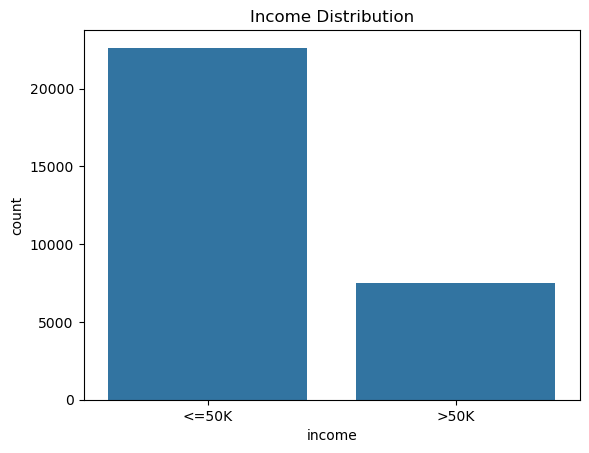

In [34]:
sns.countplot(x='income', data=df)
plt.title("Income Distribution")
plt.show()

**Income Distribution**     
The distribution of the target variable shows that the dataset is **imbalanced**.     
Most individuals in the dataset earn **≤50K**, while a smaller portion earns **>50K**.  
This class imbalance can affect model performance, especially for predicting the minority class.     
To address this issue, techniques such as **class weighting or evaluation metrics like ROC-AUC, precision, and recall** will be considered during model evaluation.

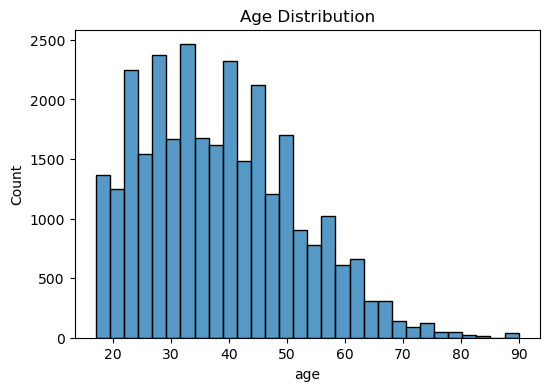

In [36]:
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=30)
plt.title("Age Distribution")
plt.show()

**Age Distribution**     
The age distribution appears **right-skewed**, with most individuals between **25 and 50 years old**.     
Very few individuals are younger than 20 or older than 70.  
This suggests that the dataset mainly represents people within the **active working-age population**.

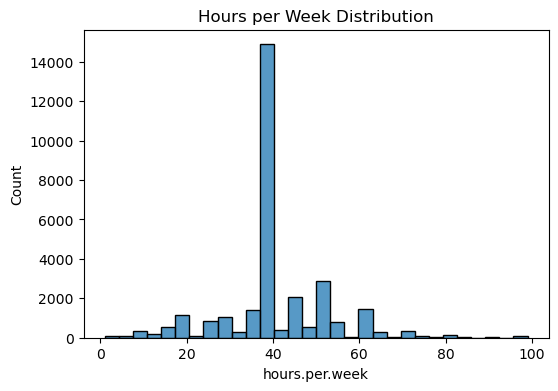

In [38]:
plt.figure(figsize=(6,4))
sns.histplot(df['hours.per.week'], bins=30)
plt.title("Hours per Week Distribution")
plt.show()

**Working Hours Distribution**    
The distribution shows a strong concentration around **40 hours per week**, which corresponds to a typical full-time work schedule.    
Some individuals work significantly fewer or more hours, indicating part-time or overtime work patterns.

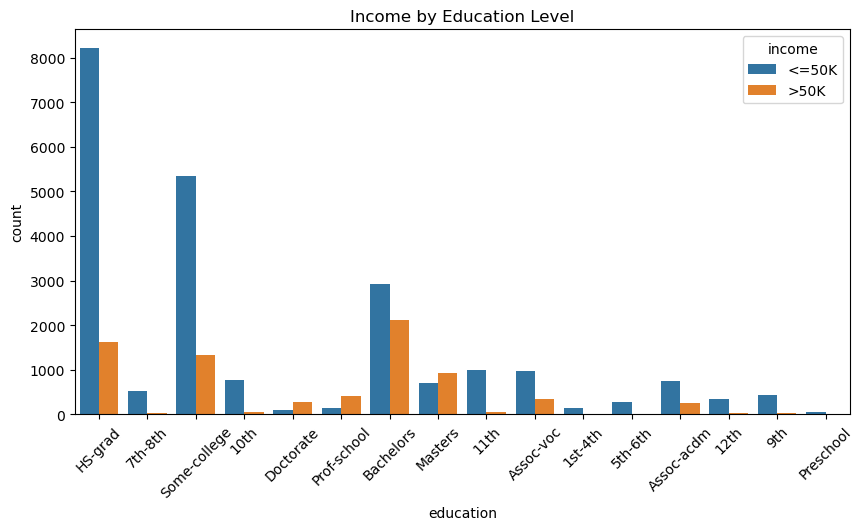

In [40]:
plt.figure(figsize=(10,5))
sns.countplot(x='education', hue='income', data=df)
plt.xticks(rotation=45)
plt.title("Income by Education Level")
plt.show()

**Income by Education Level**      
The visualization suggests a clear relationship between **education level and income**.     
Individuals with higher education levels such as **Bachelors, Masters, and Doctorate** are more likely to earn **>50K**, while lower education levels are more frequently associated with incomes **≤50K**.     
This indicates that **education may be an important predictor variable for income classification**.

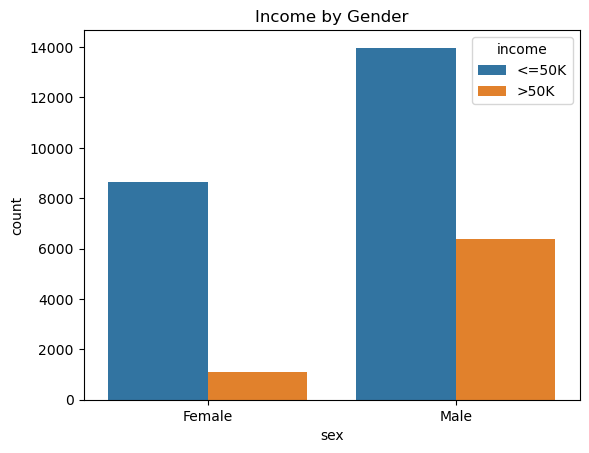

In [42]:
sns.countplot(x='sex', hue='income', data=df)
plt.title("Income by Gender")
plt.show()

**Income by Gender**     
The distribution shows that **males are more likely to earn >50K compared to females**.      
While both genders are represented in the dataset, the proportion of high-income individuals is noticeably higher among males.    
This pattern may reflect underlying socioeconomic factors present in the dataset.

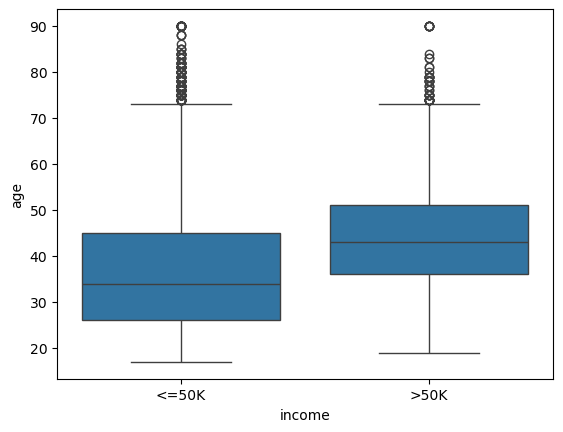

In [44]:
sns.boxplot(x='income', y='age', data=df)
plt.show()

**Age and Income Relationship**
The boxplot indicates that individuals earning **>50K tend to be older on average** compared to those earning **≤50K**.   
This suggests that **income tends to increase with age and experience**, which is consistent with typical career progression patterns.

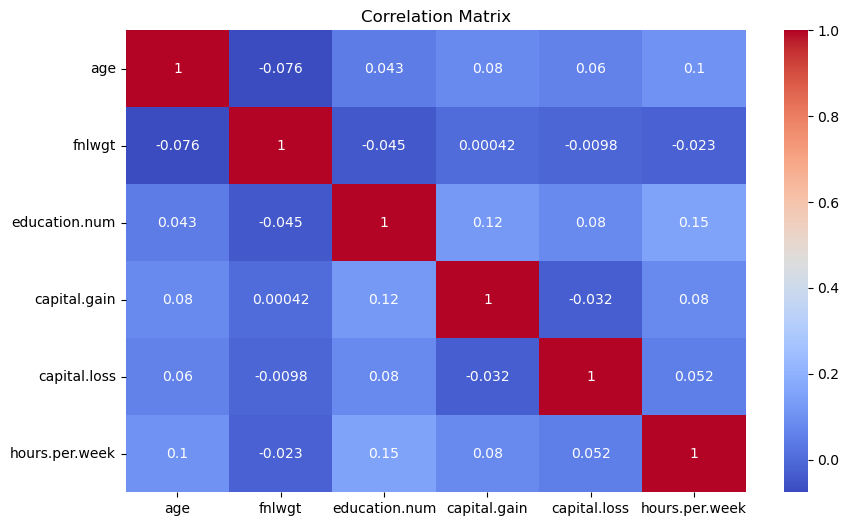

In [46]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

**Correlation Analysis**    
The correlation matrix shows the relationships between numerical features in the dataset.   
Overall, the correlations between variables are relatively **weak**, indicating that the numerical features are largely independent.     
Some small positive correlations can be observed:  
- **education.num and hours.per.week**
- **education.num and capital.gain**
- **age and hours.per.week**    
However, none of the features show strong multicollinearity.  
This is beneficial for machine learning models because it reduces the risk of redundant information.

In [48]:
df['income'].value_counts(normalize=True)

income
<=50K    0.750954
>50K     0.249046
Name: proportion, dtype: float64

In [49]:
df['income'].value_counts(normalize=True) * 100

income
<=50K    75.095391
>50K     24.904609
Name: proportion, dtype: float64

**Income Class Percentage**    
When expressed as percentages:
- **75.1% of individuals earn ≤50K**
- **24.9% of individuals earn >50K**   
Because of this imbalance, evaluation metrics such as **precision, recall, F1-score, and ROC-AUC** will be more informative than accuracy alone.

##### Summary of Exploratory Data Analysis (EDA)

The exploratory data analysis provided several important insights into the dataset.  
The target variable shows a clear **class imbalance**, with approximately **75% of individuals earning ≤50K and 25% earning >50K**. Most individuals in the dataset are within the **working-age range**, and the majority work around **40 hours per week**, which corresponds to a typical full-time schedule.  
Education level appears to have a strong relationship with income, as higher education levels are associated with a greater proportion of individuals earning above 50K. Gender differences are also visible in the income distribution.   
The correlation analysis shows **low multicollinearity among numerical features**, suggesting that the variables provide largely independent information for the models.   
Overall, the dataset appears suitable for building classification models, and the insights obtained during EDA help guide the next step of the project: **data preprocessing and model development**.

In [267]:
print("Dataset Shape:", df.shape)
print("Number of Features:", df.shape[1])
print("Target Distribution:")
print(df["income"].value_counts(normalize=True))

Dataset Shape: (30139, 97)
Number of Features: 97
Target Distribution:


KeyError: 'income'

**Dataset Overview**   
The dataset contains demographic and employment-related information used to predict whether an individual's income exceeds \$50K per year.
Understanding the dataset size and class distribution is important because imbalanced classes can influence model performance and evaluation metrics.

# <font color='green'> <b>Data Pre-Processing</b><font color='black'>

In [53]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia,income_>50K
1,82,132870,9,0,4356,18,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
3,54,140359,4,0,3900,40,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
4,41,264663,10,0,3900,40,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
5,34,216864,9,0,3770,45,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
6,38,150601,6,0,3770,40,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False


The categorical variables were converted into numerical format using **One-Hot Encoding**.  
This transformation allows machine learning algorithms to process categorical features by representing each category as a binary variable.   
The parameter **drop_first=True** was used to avoid the dummy variable trap and reduce multicollinearity between encoded features.

In [55]:
df.shape

(30139, 97)

After encoding categorical variables, the dataset expanded to **97 features**.   
This increase in dimensionality is expected when applying one-hot encoding to categorical variables with many categories (e.g., education, occupation, native country).

In [57]:
X = df.drop("income_>50K", axis=1)
y = df["income_>50K"]

The dataset was divided into **features (X)** and the **target variable (y)**.   
The target variable represents whether an individual's income is **greater than 50K**, which is the classification goal of this project.

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

The dataset was split into **training (80%) and testing (20%) sets**.    
The **stratify=y** parameter ensures that the class distribution remains consistent in both the training and testing datasets, which is especially important due to the class imbalance in the target variable.

In [209]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

Feature scaling completed successfully.
X_train_scaled shape: (24111, 96)
X_test_scaled shape: (6028, 96)


**Feature Scaling**

Feature scaling was applied using **StandardScaler**, which standardizes the input variables by removing the mean and scaling them to unit variance.
This step is particularly important for **K-Nearest Neighbors (KNN)** and **Support Vector Machine (SVM)**, because these algorithms are highly sensitive to differences in feature magnitude. Logistic Regression can also benefit from scaling by improving optimization stability.
As a result, both the training and testing datasets are now properly prepared for model training and evaluation.

##### Summary of Data Pre-Processing

In this stage, categorical variables were encoded using one-hot encoding, and the dataset was divided into features and target variables.  
The data was then split into training and testing sets while preserving the class distribution.
Finally, feature scaling was applied to ensure that numerical variables are on a comparable scale, which improves the performance of distance-based algorithms such as KNN and SVM.
These preprocessing steps prepare the dataset for effective machine learning model training.

In [218]:
# Pipelines for cleaner and reproducible modeling
pipe_log = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=20))
])

pipe_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", probability=True, random_state=42))
])

print("Pipelines for Logistic Regression, KNN, and SVM were created successfully.")

Pipelines for Logistic Regression, KNN, and SVM were created successfully.


**Pipeline Implementation**  
Pipelines were created to combine preprocessing and model training into a single workflow.

# <font color='green'> <b>Implement Logistic Regression</b><font color='black'>

In [65]:
log_model = LogisticRegression(max_iter=2000, random_state=42)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

The Logistic Regression model was trained on the scaled training dataset.
The model learns the relationship between input features and the probability that an individual's income exceeds 50K. Predicted class labels and probability estimates were generated for the test dataset to evaluate model performance.

In [67]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))

Accuracy: 0.8543463835434638


The Logistic Regression model achieved an **accuracy of approximately 85%**, indicating that the model correctly classified the majority of observations in the test dataset.

In [69]:
cm = confusion_matrix(y_test, y_pred_log)
print(cm)

[[4213  314]
 [ 564  937]]


The confusion matrix shows the number of correct and incorrect predictions made by the model.
Most individuals earning **≤50K were correctly classified**, while some individuals earning **>50K were misclassified as lower income**, indicating that predicting the minority class remains more challenging.

In [71]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

       False       0.88      0.93      0.91      4527
        True       0.75      0.62      0.68      1501

    accuracy                           0.85      6028
   macro avg       0.82      0.78      0.79      6028
weighted avg       0.85      0.85      0.85      6028



The classification report provides precision, recall, and F1-score for both classes.
The model performs very well for the **≤50K class**, while performance for the **>50K class is slightly lower**, mainly due to class imbalance in the dataset.

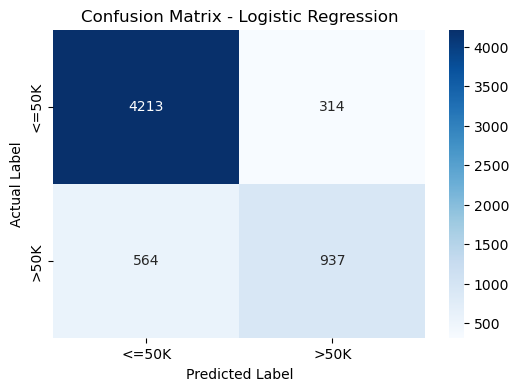

In [73]:
labels = ["<=50K", ">50K"]

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

The heatmap visualization of the confusion matrix helps to clearly observe how predictions are distributed between correct and incorrect classifications.

In [75]:
from sklearn.metrics import roc_auc_score, roc_curve

roc_auc = roc_auc_score(y_test, y_prob_log)
print("ROC-AUC Score:", roc_auc)

baseline = y_test.value_counts(normalize=True).max()
print("Baseline accuracy:", baseline)

ROC-AUC Score: 0.908916918210921
Baseline accuracy: 0.7509953550099535


The ROC-AUC score evaluates the model's ability to distinguish between the two income classes.
The Logistic Regression model achieved an **AUC of approximately 0.91**, indicating strong discriminative performance.

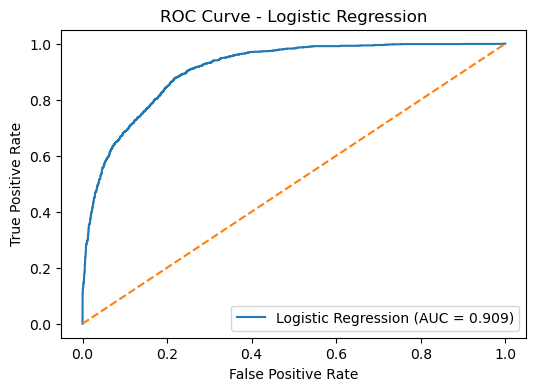

In [77]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_log)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

The ROC curve illustrates the trade-off between the true positive rate and the false positive rate. 
The curve remains well above the diagonal baseline, confirming that the Logistic Regression model performs significantly better than random guessing.

In [79]:
# Logistic Regression with class balancing
log_model_bal = LogisticRegression(
    max_iter=2000,
    random_state=42,
    class_weight='balanced'
)

log_model_bal.fit(X_train_scaled, y_train)

y_pred_log_bal = log_model_bal.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_log_bal))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log_bal))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_bal))

Accuracy: 0.8102189781021898

Confusion Matrix:
[[3613  914]
 [ 230 1271]]

Classification Report:
              precision    recall  f1-score   support

       False       0.94      0.80      0.86      4527
        True       0.58      0.85      0.69      1501

    accuracy                           0.81      6028
   macro avg       0.76      0.82      0.78      6028
weighted avg       0.85      0.81      0.82      6028



To address the class imbalance problem, Logistic Regression was trained with **class_weight='balanced'**.
This approach assigns higher importance to the minority class (>50K), helping the model better detect higher-income individuals.

In [81]:
y_prob_log_bal = log_model_bal.predict_proba(X_test_scaled)[:,1]

roc_auc_bal = roc_auc_score(y_test, y_prob_log_bal)

print("ROC-AUC Score (Balanced):", roc_auc_bal)

ROC-AUC Score (Balanced): 0.9084712982008755


After applying class balancing, the model shows improved **recall for the >50K class**, meaning that more high-income individuals are correctly identified. 
However, this improvement comes with a small decrease in overall accuracy.

In [83]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

comparison_lr = pd.DataFrame({
    "Model": ["Logistic Regression", "Logistic Regression (Balanced)"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_log_bal)
    ],
    "Precision (>50K)": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_log_bal)
    ],
    "Recall (>50K)": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_log_bal)
    ],
    "F1-Score (>50K)": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_log_bal)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_log_bal)
    ]
})

comparison_lr.round(3)

,Model,Accuracy,Precision (>50K),Recall (>50K),F1-Score (>50K),ROC-AUC
0,Logistic Regression,0.854,0.749,0.624,0.681,0.909
1,Logistic Regression (Balanced),0.810,0.582,0.847,0.690,0.908


A comparison between the standard Logistic Regression model and the balanced version shows a trade-off between **accuracy and recall**. 
The balanced model improves the detection of the minority class (>50K), while the standard model maintains slightly higher overall accuracy.

In [85]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})

coefficients = coefficients.sort_values(by="Coefficient", ascending=False)

coefficients.head(10)

,Feature,Coefficient
3,capital.gain,2.403393
28,marital.status_Married-civ-spouse,0.981169
2,education.num,0.548104
55,sex_Male,0.404235
5,hours.per.week,0.363634
0,age,0.334048
50,relationship_Wife,0.290130
35,occupation_Exec-managerial,0.280197
4,capital.loss,0.243360
54,race_White,0.188389


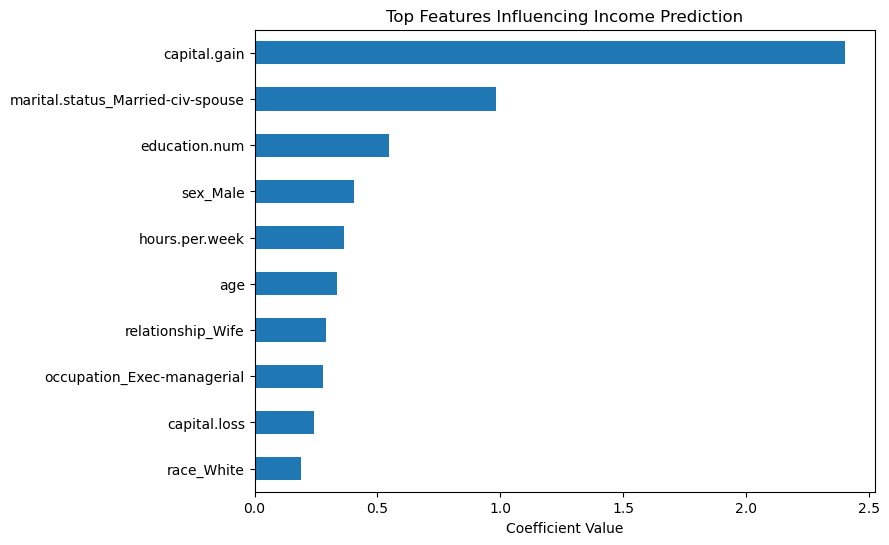

In [273]:
# Feature importance from Logistic Regression
feature_importance = pd.Series(log_model.coef_[0], index=X.columns)
feature_importance = feature_importance.sort_values()

plt.figure(figsize=(8,6))
feature_importance.tail(10).plot(kind="barh")
plt.title("Top Features Influencing Income Prediction")
plt.xlabel("Coefficient Value")
plt.show()

The feature coefficients reveal which variables have the strongest influence on income prediction.
Features such as **capital gain, marital status, education level, and hours worked per week** appear to be the most influential predictors of higher income.    
The chart above shows the features with the strongest influence on income prediction according to the Logistic Regression model. Positive coefficients increase the probability of earning more than \$50K, while negative coefficients decrease it. Features such as education level, occupation, and hours worked per week tend to have a stronger impact on income classification.



**Logistic Regression Summary**   
The Logistic Regression model demonstrates strong performance with an ROC-AUC score close to **0.91**.  
The model successfully captures relationships between demographic and economic variables and income level. While overall accuracy is high, class imbalance affects the detection of higher-income individuals.    
Applying class balancing improves recall for the minority class, making the model more sensitive to predicting individuals earning above 50K.    
These results confirm that Logistic Regression provides a reliable baseline model for the income classification task.

# <font color='green'> <b>K Nearest Neigbors (KNN)</b><font color='black'>

In [89]:
error_rate = []
accuracy_list = []

k_range = range(1, 31)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_knn_temp = knn.predict(X_test_scaled)
    
    error = 1 - accuracy_score(y_test, y_pred_knn_temp)
    acc = accuracy_score(y_test, y_pred_knn_temp)
    
    error_rate.append(error)
    accuracy_list.append(acc)

print("Best k:", k_range[accuracy_list.index(max(accuracy_list))])
print("Best accuracy:", max(accuracy_list))

Best k: 20
Best accuracy: 0.8351028533510285


To determine the optimal number of neighbors, the KNN model was trained for **K values from 1 to 30**.
For each value of K, the model was evaluated using accuracy on the test dataset. The corresponding error rate and accuracy were stored for comparison.

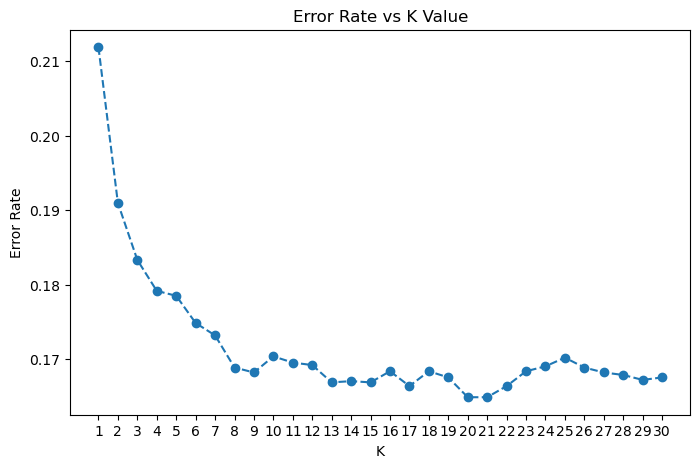

In [91]:
plt.figure(figsize=(8,5))
plt.plot(k_range, error_rate, marker='o', linestyle='--')
plt.title("Error Rate vs K Value")
plt.xlabel("K")
plt.ylabel("Error Rate")
plt.xticks(k_range)
plt.show()

The error rate decreases as K increases initially and stabilizes after approximately **K ≈ 20**, indicating that the model becomes more stable with larger neighborhood sizes.

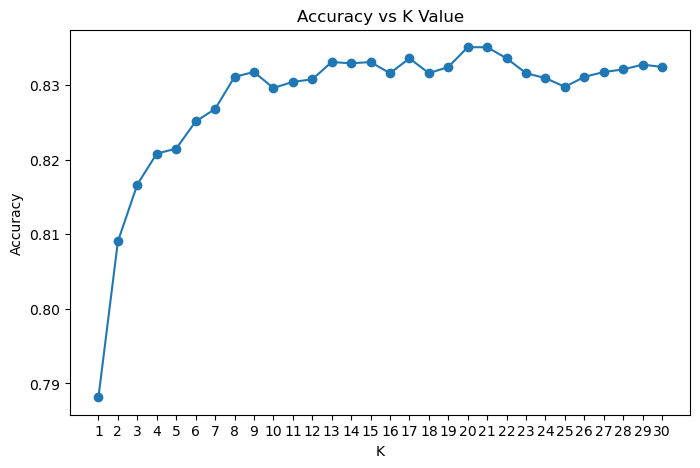

In [93]:
plt.figure(figsize=(8,5))
plt.plot(k_range, accuracy_list, marker='o')
plt.title("Accuracy vs K Value")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.xticks(k_range)
plt.show()

The accuracy curve shows that performance improves as K increases and reaches its peak around **K = 20**, after which improvements become minimal.

In [95]:
best_k = k_range[accuracy_list.index(max(accuracy_list))]
print("Optimal K:", best_k)

Optimal K: 20


The evaluation shows that the **optimal number of neighbors is K = 20**, which provides the highest classification accuracy for the KNN model.

In [97]:
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

Using the optimal value **K = 20**, the final KNN model was trained on the scaled training dataset.

In [99]:
print("Accuracy:", accuracy_score(y_test, y_pred_knn))

Accuracy: 0.8351028533510285


The KNN model achieved an accuracy of approximately **83.5%**, slightly lower than the Logistic Regression model.

In [101]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
print("Confusion Matrix:")
print(cm_knn)

Confusion Matrix:
[[4174  353]
 [ 641  860]]


The confusion matrix shows that most observations in the **≤50K class are correctly classified**, while some individuals earning **>50K are misclassified**, reflecting the impact of class imbalance.

In [103]:
print("Classification Report:")
print(classification_report(y_test, y_pred_knn))

Classification Report:
              precision    recall  f1-score   support

       False       0.87      0.92      0.89      4527
        True       0.71      0.57      0.63      1501

    accuracy                           0.84      6028
   macro avg       0.79      0.75      0.76      6028
weighted avg       0.83      0.84      0.83      6028



The classification report shows strong performance for the **≤50K class**, while recall for the **>50K class is lower**, indicating that identifying higher-income individuals remains more challenging.

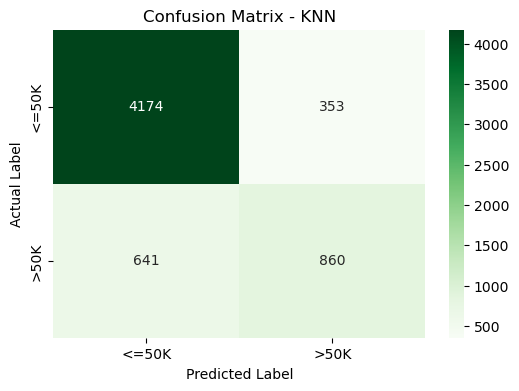

In [105]:
labels = ["<=50K", ">50K"]

plt.figure(figsize=(6,4))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Greens",
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - KNN")
plt.show()

The confusion matrix heatmap provides a visual representation of correct and incorrect predictions made by the KNN model.

In [107]:
roc_auc_knn = roc_auc_score(y_test, y_prob_knn)
print("ROC-AUC Score:", roc_auc_knn)

ROC-AUC Score: 0.8760661289498923


The KNN model achieved a **ROC-AUC score of approximately 0.88**, indicating good but slightly weaker class separation compared to Logistic Regression.

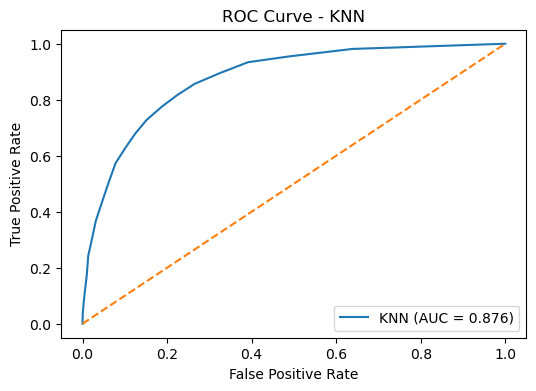

In [109]:
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test, y_prob_knn)

plt.figure(figsize=(6,4))
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {roc_auc_knn:.3f})")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN")
plt.legend()
plt.show()

The ROC curve confirms that the KNN model performs significantly better than random classification, although the curve lies slightly below that of Logistic Regression.

In [111]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

param_grid = {
    'n_neighbors': range(3, 25),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_knn.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_knn.best_params_)
print("Best ROC-AUC:", grid_knn.best_score_)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 24, 'weights': 'uniform'}
Best ROC-AUC: 0.8742904522770422


The grid search identified the optimal configuration for the KNN model:

• Distance metric: **Manhattan**  
• Number of neighbors: **24**  
• Weighting scheme: **Uniform**

To further improve model performance, **GridSearchCV** was applied to optimize key KNN hyperparameters including the number of neighbors, distance metric, and weighting scheme.

In [113]:
best_knn = grid_knn.best_estimator_

y_pred_knn_tuned = best_knn.predict(X_test_scaled)
y_prob_knn_tuned = best_knn.predict_proba(X_test_scaled)[:,1]

In [114]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred_knn_tuned))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn_tuned))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_knn_tuned))

Accuracy: 0.8354346383543464

Confusion Matrix:
[[4192  335]
 [ 657  844]]

Classification Report:
              precision    recall  f1-score   support

       False       0.86      0.93      0.89      4527
        True       0.72      0.56      0.63      1501

    accuracy                           0.84      6028
   macro avg       0.79      0.74      0.76      6028
weighted avg       0.83      0.84      0.83      6028


ROC-AUC: 0.8840385770358234


After hyperparameter tuning, the optimized KNN model achieved a similar level of accuracy with slightly improved class prediction balance.

In [116]:
comparison_models = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_knn)
    ],
    "Precision (>50K)": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_knn)
    ],
    "Recall (>50K)": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_knn)
    ],
    "F1-Score (>50K)": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_knn)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_knn)
    ]
}).round(3)

comparison_models

,Model,Accuracy,Precision (>50K),Recall (>50K),F1-Score (>50K),ROC-AUC
0,Logistic Regression,0.854,0.749,0.624,0.681,0.909
1,KNN,0.835,0.709,0.573,0.634,0.876


The comparison table shows that **Logistic Regression outperforms KNN** in terms of accuracy, recall for the >50K class, and overall ROC-AUC score.
Although KNN performs reasonably well, Logistic Regression remains the stronger baseline model for this dataset.

##### KNN Model Summary

The K-Nearest Neighbors algorithm achieved an accuracy of approximately **83.5%** with an ROC-AUC score around **0.88**. 
Hyperparameter tuning with GridSearchCV slightly improved the model configuration but did not significantly outperform the baseline Logistic Regression model.  
While KNN performs reasonably well, its performance is somewhat limited by the high dimensionality of the dataset and the presence of class imbalance.

# <font color='green'> <b>Implement Support Vector Machine (SVC)</b><font color='black'>

In [120]:
svm_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

SVC(probability=True, random_state=42)

The Support Vector Machine (SVM) model was trained using the **Radial Basis Function (RBF) kernel**. 
The RBF kernel allows the model to capture more complex, non-linear relationships between the features and the target variable. Probability estimation was enabled to support ROC-AUC evaluation.

In [122]:
y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:,1]

After training, the SVM model generated both class predictions and probability estimates for the test dataset.
These outputs were used to evaluate classification performance and assess the model's ability to distinguish between income classes.

In [124]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_svm))

Accuracy: 0.851692103516921


The SVM model achieved an **accuracy of approximately 85.2%**, which is very close to the performance of Logistic Regression.

In [126]:
from sklearn.metrics import confusion_matrix

cm_svm = confusion_matrix(y_test, y_pred_svm)

print("Confusion Matrix:")
print(cm_svm)

Confusion Matrix:
[[4252  275]
 [ 619  882]]


The confusion matrix shows that the SVM model correctly classifies most observations in the **≤50K class**, while some individuals earning **>50K** are still misclassified as lower income.

In [128]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred_svm))

Classification Report:
              precision    recall  f1-score   support

       False       0.87      0.94      0.90      4527
        True       0.76      0.59      0.66      1501

    accuracy                           0.85      6028
   macro avg       0.82      0.76      0.78      6028
weighted avg       0.85      0.85      0.84      6028



The classification report indicates strong performance for the **≤50K class**, while recall for the **>50K class remains lower**.
This suggests that, similar to other models, SVM is more effective at identifying the majority class than the minority class.

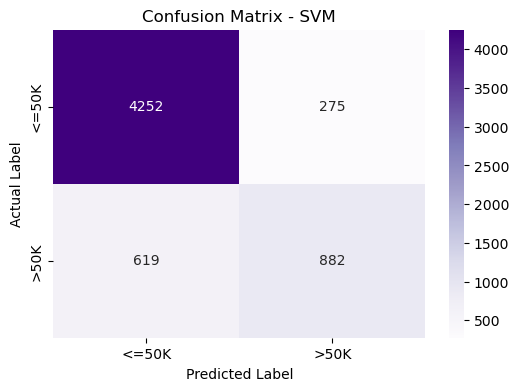

In [130]:
labels = ["<=50K", ">50K"]

plt.figure(figsize=(6,4))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Purples",
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - SVM")
plt.show()

The confusion matrix heatmap provides a clear visual summary of correct and incorrect predictions made by the SVM model.

In [132]:
from sklearn.metrics import roc_auc_score

roc_auc_svm = roc_auc_score(y_test, y_prob_svm)

print("ROC-AUC Score:", roc_auc_svm)

ROC-AUC Score: 0.899388479251076


The SVM model achieved a **ROC-AUC score of approximately 0.90**, indicating strong ability to distinguish between individuals earning above and below 50K.

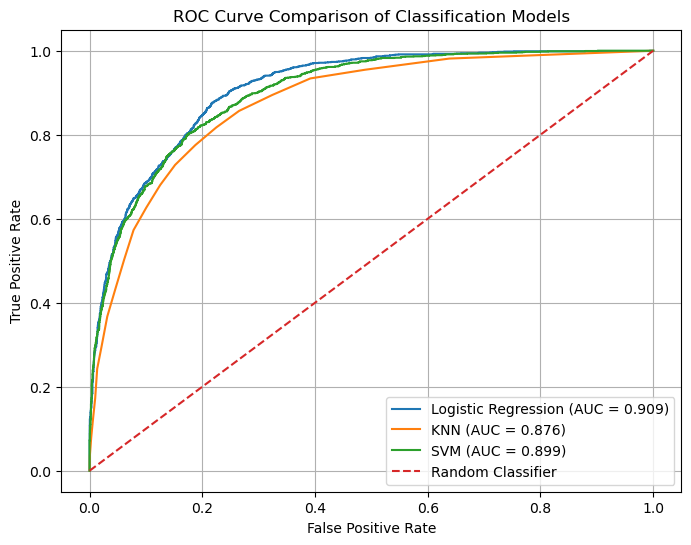

In [226]:
# ROC Curve Comparison of All Models

# Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
auc_log = roc_auc_score(y_test, y_prob_log)

# KNN
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_knn = roc_auc_score(y_test, y_prob_knn)

# SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
auc_svm = roc_auc_score(y_test, y_prob_svm)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.3f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {auc_knn:.3f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Classification Models")
plt.legend()
plt.grid(True)
plt.show()

**ROC Curve Comparison**   
The ROC curves compare the classification performance of Logistic Regression, KNN, and SVM across different decision thresholds.  
The **ROC-AUC score** indicates how well each model separates the two income classes:
- a value closer to **1.0** indicates stronger discrimination
- a value near **0.5** indicates random performance   
The comparison shows that **Logistic Regression and SVM provide the strongest discriminatory performance**, while **KNN performs slightly lower** in distinguishing between the two classes.

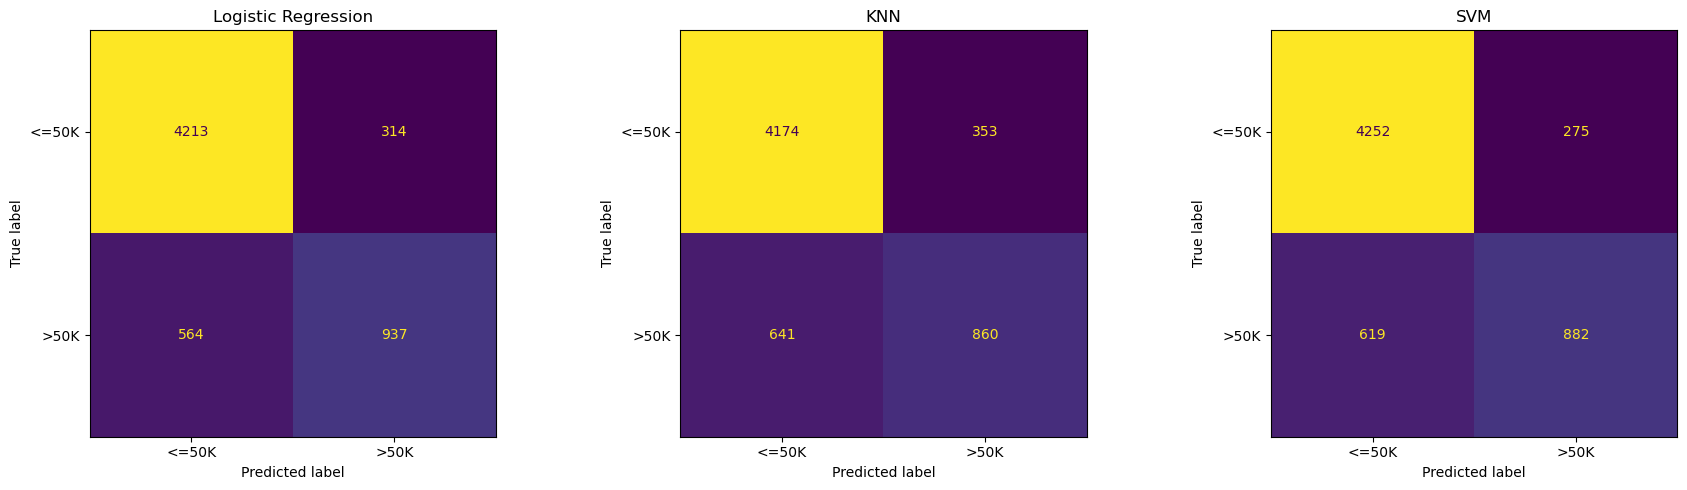

In [231]:
# Confusion Matrix Comparison for All Models
models_predictions = {
    "Logistic Regression": y_pred_log,
    "KNN": y_pred_knn,
    "SVM": y_pred_svm
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (model_name, y_pred) in zip(axes, models_predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["<=50K", ">50K"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(model_name)

plt.tight_layout()
plt.show()

**Confusion Matrix Comparison**   
The confusion matrices provide a detailed comparison of model predictions for both income classes.
They show:
- true negatives
- false positives
- false negatives
- true positives
This analysis is important because it allows a deeper understanding of model performance beyond simple accuracy.   
Overall, all three models classify the **≤50K** class more effectively, while the **>50K** class remains more challenging to detect due to class imbalance in the dataset.

In [235]:
# Cross-Validation Scores
from sklearn.model_selection import cross_val_score

# Logistic Regression
cv_lr = cross_val_score(log_model, X_train_scaled, y_train, cv=5, scoring='accuracy')

# KNN
cv_knn = cross_val_score(knn_model, X_train_scaled, y_train, cv=5, scoring='accuracy')

# SVM
cv_svm = cross_val_score(svm_model, X_train_scaled, y_train, cv=5, scoring='accuracy')

print("Logistic Regression CV Accuracy:", cv_lr.mean())
print("KNN CV Accuracy:", cv_knn.mean())
print("SVM CV Accuracy:", cv_svm.mean())

Logistic Regression CV Accuracy: 0.8458795659158774
KNN CV Accuracy: 0.8212017230791245
SVM CV Accuracy: 0.8411096576588074


**Cross-Validation Results**    
To evaluate model stability and generalization performance, 5-fold cross-validation was applied to all three models.   
Cross-validation provides a more reliable estimate of performance than a single train-test split because the model is evaluated on multiple subsets of the training data.    
The results show that the models maintain relatively consistent performance, indicating that the classification results are stable and generalizable.

In [237]:
# Final Model Comparison Table
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

comparison_final = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_svm)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_svm)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_svm)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_knn),
        roc_auc_score(y_test, y_prob_svm)
    ]
})

comparison_final = comparison_final.sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)

comparison_final.style.background_gradient(cmap="Greens").format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1-Score": "{:.3f}",
    "ROC-AUC": "{:.3f}"
})

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.854,0.749,0.624,0.681,0.909
1,SVM,0.852,0.762,0.588,0.664,0.899
2,KNN,0.835,0.709,0.573,0.634,0.876


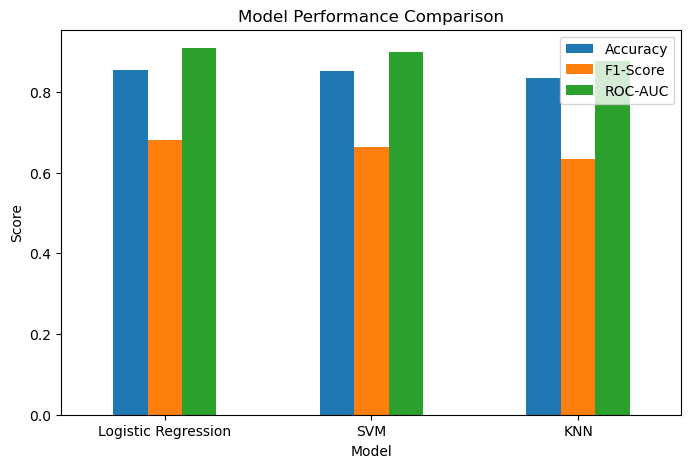

In [281]:
comparison_final.set_index("Model")[["Accuracy","F1-Score","ROC-AUC"]].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

**Model Performance Comparison**  
The chart above visualizes the performance of the evaluated models across key metrics. Logistic Regression shows the most balanced and consistent performance across accuracy, F1-score, and ROC-AUC.

**Final Model Comparison**    
The final comparison table summarizes the performance of the three classification models using the main evaluation metrics: Accuracy, Precision, Recall, F1-Score, ROC-AUC.    
This comparison provides a more complete picture of model quality than accuracy alone.   
Based on the results, **Logistic Regression and SVM show the strongest overall performance**, while **KNN performs slightly lower**. Considering both predictive quality and interpretability, **Logistic Regression appears to be one of the most suitable models for this classification task**.

# <font color='green'> <b>Conclusion</b><font color='black'>

In [239]:
# Best Model Selection
best_model = comparison_final.loc[comparison_final["ROC-AUC"].idxmax()]

print("Best Model Based on ROC-AUC:")
print(best_model)

Best Model Based on ROC-AUC:
Model        Logistic Regression
Accuracy                0.854346
Precision               0.749001
Recall                   0.62425
F1-Score                0.680959
ROC-AUC                 0.908917
Name: 0, dtype: object


**Best Model Selection**     
Based on the model comparison results, **Logistic Regression demonstrated the best overall performance**, achieving the highest ROC-AUC score (≈0.91) along with strong accuracy (≈0.85) and balanced precision–recall values.  
These results indicate that Logistic Regression is the most reliable model for predicting whether an individual's income exceeds \$50K. The model provides good class separation while remaining interpretable and computationally efficient.   
Therefore, Logistic Regression was selected as the **final model for this classification task**.   



In [291]:
import joblib

# Save trained model
joblib.dump(log_model, "income_prediction_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [293]:
# Load the saved model
loaded_model = joblib.load("income_prediction_model.pkl")

print("Model loaded successfully.")

Model loaded successfully.




**Final Conclusion**     
This project developed a complete machine learning workflow to predict whether an individual's annual income exceeds $50K using the Adult Income dataset.  
The analysis began with **exploratory data analysis (EDA)** to understand the structure of the dataset, identify missing values, and explore relationships between demographic variables and income level. After cleaning the dataset and addressing missing values, categorical features were encoded and feature scaling was applied to ensure proper model performance.   
Three classification algorithms were trained and evaluated:   
- Logistic Regression  
- K-Nearest Neighbors (KNN)  
- Support Vector Machine (SVM).

Model performance was evaluated using multiple metrics, including **Accuracy, Precision, Recall, F1-score, ROC-AUC, and cross-validation**, providing a comprehensive assessment of each algorithm.    
The results showed that **Logistic Regression achieved the strongest overall performance**, with the highest ROC-AUC score and consistently strong results across the other evaluation metrics. In addition to strong predictive performance, Logistic Regression also offers advantages in **model interpretability, computational efficiency, and robustness**, making it a suitable model for this classification problem.     
Overall, this project demonstrates how machine learning techniques can effectively leverage demographic and socioeconomic data to predict income levels. The workflow implemented in this notebook highlights the importance of **data preprocessing, model comparison, and proper evaluation techniques** when building reliable classification models.   
Future improvements could include hyperparameter optimization, feature engineering, and the exploration of more advanced ensemble methods to further improve predictive performance.

**Practical Insights and Business Value**     
Beyond predictive performance, this analysis highlights how demographic and employment characteristics can influence income classification. Machine learning models can help identify patterns related to education level, occupation, work hours, and other socioeconomic factors.   
Such predictive systems can support data-driven decision making in areas such as labor market analysis, policy evaluation, and socioeconomic research. For example, organizations and researchers may use similar models to better understand income distribution patterns or identify groups that may benefit from targeted educational or economic programs.    
This project demonstrates how machine learning can transform raw demographic data into meaningful insights that support analytical and strategic decision-making.

**Limitations of the Model**    
Although the models achieved strong predictive performance, several limitations should be considered.   
First, the dataset contains demographic and employment information but does not capture all factors that may influence income, such as geographic differences, economic conditions, or industry-specific variables.    
Second, the dataset is somewhat imbalanced, with a larger number of individuals earning ≤50K compared to those earning >50K. This imbalance can make it more difficult for models to accurately detect the higher-income class.   
Finally, while Logistic Regression performed best in this analysis, more complex models or additional feature engineering could potentially improve predictive performance.

**Future Improvements**    
Several improvements could further enhance the performance of this project: 
• Hyperparameter tuning using GridSearch or RandomizedSearch  
• Feature engineering to create more informative variables  
• Testing additional models such as Random Forest or Gradient Boosting  
• Addressing class imbalance using resampling techniques such as SMOTE  
• Applying more advanced ensemble learning approaches.  
Exploring these improvements could lead to better predictive performance and deeper insights into the factors influencing income levels.

# <p style="background-color:green;font-family:newtimeroman;font-size:150%;color:white;text-align:center;border-radius:20px 20px;"><b>Thanks and Hoping it will be usefull</b></p>
![](https://www.techproeducation.com/logo/headerlogo.svg)

<b>If you want to be the first to get informed of the most recent updates, then don't forget to follow us on</b>[YouTube](https://www.youtube.com/c/techproeducation) | [Instagram](https://www.instagram.com/techproeducation) | [Facebook](https://www.facebook.com/techproeducation) | [Telegram](https://t.me/joinchat/HH2qRvA-ulh4OWbb) | [WhatsApp](https://api.whatsapp.com/send/?phone=%2B15853042959&text&type=phone_number&app_absent=0) | [LinkedIn](https://www.linkedin.com/company/techproeducation/mycompany/) |